# BIM 322 - Solar Guc Uretim Tahmini

**Ogrenciler:** Busra Demir & Nazenin Tatar  
**Ders:** BIM 322 - Makine Ogrenmesi  
**Veri Seti:** Solar Power Generation Dataset  
**Hedef:** AC_POWER degerinden yuksek/dusuk uretim siniflandirmasi

Bu projede iki güneş enerjisi santraline ait üretim ve hava sensörü verileri kullanılmıştır. Amaç, anlık sensör değerlerinden yola çıkarak güç üretiminin yüksek mi düşük mü olduğunu tahmin etmektir.

In [ ]:
# Gerekli kutuphaneler yuklu degilse bu hucre bir kez calistirilabilir.
!pip install -r ../requirements.txt


In [2]:
# ==================================================
# BOLUM 0 - Import ve Konfigurasyon
# ==================================================

import pandas as pd
import numpy as np
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif, RFE, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, f1_score,
    precision_recall_curve, average_precision_score
)

import shap
import warnings
warnings.filterwarnings('ignore')
print('Kutuphaneler yuklendi.')

Kutuphaneler yuklendi.


c:\Users\demir\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
# ==================================================
# BOLUM 1 - Veri Yukleme
# ==================================================

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'

# Plant 1: uretim + hava verisi
gen1_df = pd.read_csv(DATA_DIR / 'Plant_1_Generation_Data.csv')
weather1_df = pd.read_csv(DATA_DIR / 'Plant_1_Weather_Sensor_Data.csv')
gen1_df['DATE_TIME'] = pd.to_datetime(gen1_df['DATE_TIME'], dayfirst=True)
weather1_df['DATE_TIME'] = pd.to_datetime(weather1_df['DATE_TIME'])
plant1_df = pd.merge(gen1_df, weather1_df, on='DATE_TIME', how='inner')

# Plant 2: uretim + hava verisi
gen2_df = pd.read_csv(DATA_DIR / 'Plant_2_Generation_Data.csv')
weather2_df = pd.read_csv(DATA_DIR / 'Plant_2_Weather_Sensor_Data.csv')
gen2_df['DATE_TIME'] = pd.to_datetime(gen2_df['DATE_TIME'], dayfirst=True)
weather2_df['DATE_TIME'] = pd.to_datetime(weather2_df['DATE_TIME'])
plant2_df = pd.merge(gen2_df, weather2_df, on='DATE_TIME', how='inner')

df = pd.concat([plant1_df, plant2_df], ignore_index=True)

cols_to_drop = [c for c in df.columns if c.startswith('PLANT_ID') or c.startswith('SOURCE_KEY')]
df.drop(columns=cols_to_drop, inplace=True)

print(f'Plant 1 satir: {len(plant1_df)}')
print(f'Plant 2 satir: {len(plant2_df)}')
print(f'Toplam satir : {df.shape[0]}')
print(f'Sutunlar     : {list(df.columns)}')
display(df.head())


Plant 1 satir: 68774
Plant 2 satir: 67698
Toplam satir : 136472
Sutunlar     : ['DATE_TIME', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']


,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,0.0,0.0,0.0,6259559.0,25.184316,22.857507,0.0
1,2020-05-15,0.0,0.0,0.0,6183645.0,25.184316,22.857507,0.0
2,2020-05-15,0.0,0.0,0.0,6987759.0,25.184316,22.857507,0.0
3,2020-05-15,0.0,0.0,0.0,7602960.0,25.184316,22.857507,0.0
4,2020-05-15,0.0,0.0,0.0,7158964.0,25.184316,22.857507,0.0


--- 1. BOYUT VE TIP KONTROLU ---
Satir: 136472, Sutun: 8
DATE_TIME              datetime64[us]
DC_POWER                      float64
AC_POWER                      float64
DAILY_YIELD                   float64
TOTAL_YIELD                   float64
AMBIENT_TEMPERATURE           float64
MODULE_TEMPERATURE            float64
IRRADIATION                   float64
dtype: object

--- 2. ISTATISTIKSEL OZET ---


,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
count,136472,136472.000000,136472.000000,136472.000000,1.364720e+05,136472.000000,136472.000000,136472.000000
mean,2020-06-01 09:22:57.605662,1708.373962,274.790259,3295.366192,3.303916e+08,26.763066,31.920744,0.230767
min,2020-05-15 00:00:00,0.000000,0.000000,0.000000,0.000000e+00,20.398505,18.140415,0.000000
25%,2020-05-23 23:00:00,0.000000,0.000000,28.285714,6.520020e+06,23.637604,22.411698,0.000000
50%,2020-06-01 18:45:00,5.993333,3.493095,2834.642857,7.269333e+06,25.908122,26.413755,0.026213
75%,2020-06-09 21:45:00,1155.595000,532.568571,5992.000000,2.826096e+08,29.266583,40.778583,0.442961
max,2020-06-17 23:45:00,14471.125000,1410.950000,9873.000000,2.247916e+09,39.181638,66.635953,1.221652
std,NaN,3222.079306,380.180214,3035.313217,6.085769e+08,3.897340,11.803674,0.305652


--- 3. EKSIK DEGER ---
DATE_TIME              0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64


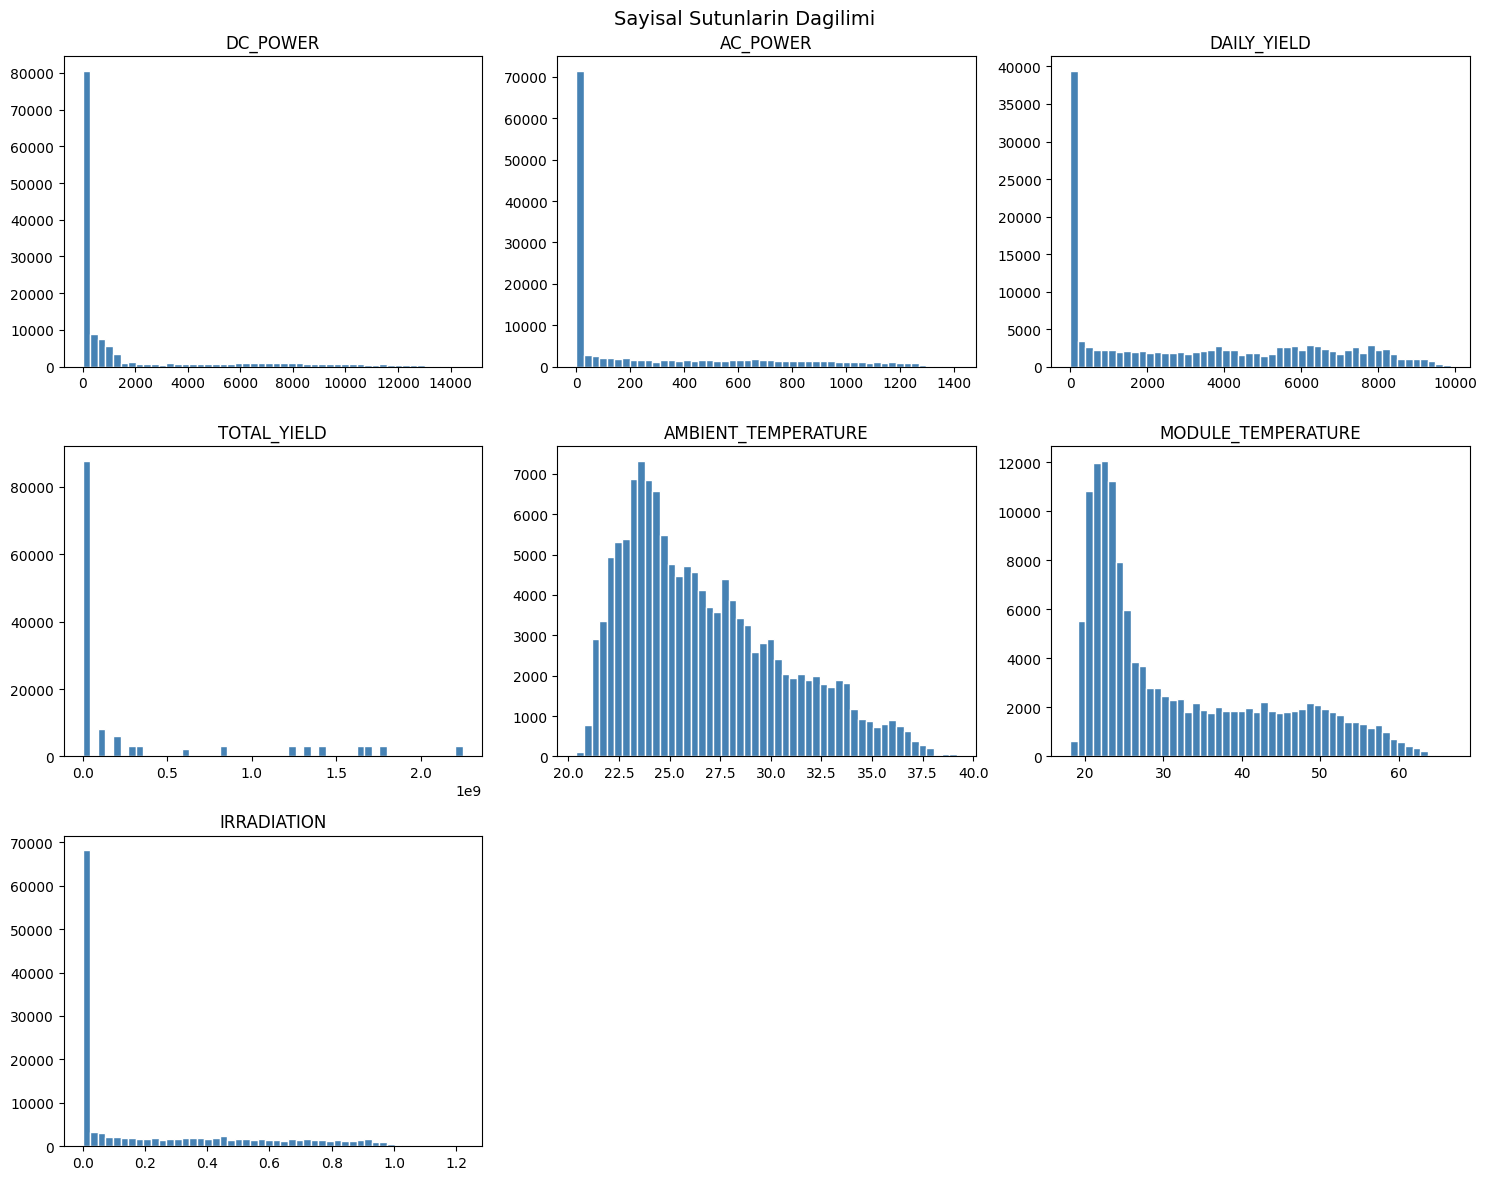

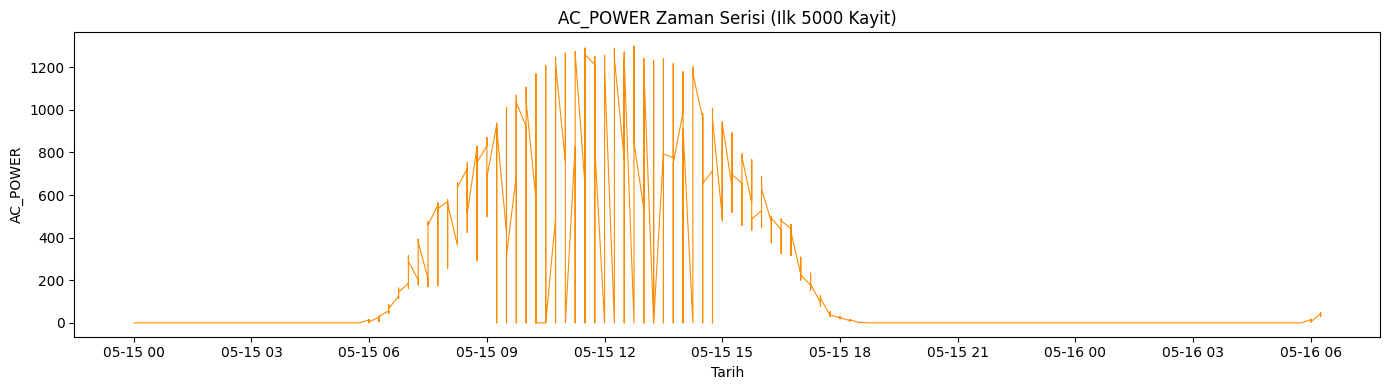

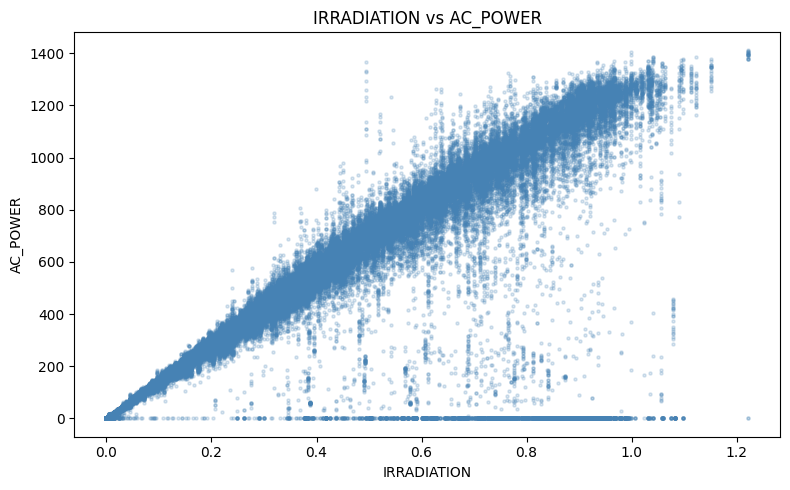

In [13]:
# ==================================================
# BOLUM 2 - Kesifsel Veri Analizi (EDA)
# ==================================================

# 1. Boyut ve tip kontrolu
print('--- 1. BOYUT VE TIP KONTROLU ---')
print(f'Satir: {df.shape[0]}, Sutun: {df.shape[1]}')
print(df.dtypes)

# 2. Istatistiksel ozet
print('\n--- 2. ISTATISTIKSEL OZET ---')
display(df.describe())

# 3. Eksik deger kontrolu
print('--- 3. EKSIK DEGER ---')
print(df.isnull().sum())

# 4. Dagilim grafikleri (histogram)
num_cols = ['DC_POWER','AC_POWER','DAILY_YIELD','TOTAL_YIELD',
            'AMBIENT_TEMPERATURE','MODULE_TEMPERATURE','IRRADIATION']
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=50)
    axes[i].set_title(col)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Sayisal Sutunlarin Dagilimi', fontsize=14)
plt.tight_layout()
plt.show()

# 5. Zaman serisi: AC_POWER
df_s = df.sort_values('DATE_TIME').head(5000)
plt.figure(figsize=(14, 4))
plt.plot(df_s['DATE_TIME'], df_s['AC_POWER'], lw=0.9)
plt.title('AC_POWER Zaman Serisi (Ilk 5000 Kayit)')
plt.xlabel('Tarih')
plt.ylabel('AC_POWER')
plt.tight_layout()
plt.show()

# 6. Scatter: IRRADIATION vs AC_POWER
plt.figure(figsize=(8, 5))
plt.scatter(df['IRRADIATION'], df['AC_POWER'], alpha=0.25, s=6)
plt.title('IRRADIATION vs AC_POWER')
plt.xlabel('IRRADIATION')
plt.ylabel('AC_POWER')
plt.tight_layout()
plt.show()

### EDA Bulgulari

Histogramlarda güç üretimi ve ışınım değerlerinin düşük aralıklarda yoğunlaştığı görülmüştür.

AC_POWER zaman serisi, gündüz saatlerinde üretimin arttığını ve gece saatlerinde sıfıra yaklaştığını göstermektedir.

IRRADIATION ile AC_POWER arasında pozitif bir ilişki vardır. Bu nedenle IRRADIATION modelleme için önemli bir aday değişkendir.

Veri setinde eksik değer problemi bulunmamıştır. Gece üretimi ve aykırı değerler modelleme öncesinde ayrıca ele alınmıştır.


In [14]:
# ==================================================
# BOLUM 3 - Veri On Isleme (Gorev 1)
# ==================================================

# 3.1 Gece satirlarini dusur (AC_POWER = 0 gurultu)
print('--- 3.1 GECE SATIRLARI ---')
print(f'Oncesi: {len(df)}')
df_day = df[df['AC_POWER'] > 0].copy()
print(f'Sonrasi (AC_POWER>0): {len(df_day)}')

# 3.2 IQR Aykiri Deger Temizligi
print('\n--- 3.2 IQR TEMIZLIGI ---')
def remove_outliers_iqr(data, columns):
    cleaned = data.copy()
    before = len(cleaned)
    for col in columns:
        Q1 = cleaned[col].quantile(0.25)
        Q3 = cleaned[col].quantile(0.75)
        IQR = Q3 - Q1
        cleaned = cleaned[(cleaned[col] >= Q1 - 1.5*IQR) & (cleaned[col] <= Q3 + 1.5*IQR)]
    print(f'Temizlenen satir: {before - len(cleaned)}')
    return cleaned

df_clean = remove_outliers_iqr(df_day, ['DC_POWER','AC_POWER','AMBIENT_TEMPERATURE','IRRADIATION'])
print(f'Temiz veri boyutu: {df_clean.shape}')

# 3.3 Train / Validation / Test Ayrimi
# Once split -> sonra binary target (data leakage yok)
print('\n--- 3.3 TRAIN/VAL/TEST AYRIMI ---')
feature_cols = ['DAILY_YIELD','TOTAL_YIELD','AMBIENT_TEMPERATURE','MODULE_TEMPERATURE','IRRADIATION']
X_all     = df_clean[feature_cols].reset_index(drop=True)
y_all_raw = df_clean['AC_POWER'].reset_index(drop=True)

X_trainval, X_test, y_trainval_raw, y_test_raw = train_test_split(
    X_all, y_all_raw, test_size=0.20, random_state=42)
X_train, X_val, y_train_raw, y_val_raw = train_test_split(
    X_trainval, y_trainval_raw, test_size=0.20, random_state=42)

total = len(X_all)
print(f'Train : {len(X_train)} ({len(X_train)/total*100:.1f}%)')
print(f'Val   : {len(X_val)}   ({len(X_val)/total*100:.1f}%)')
print(f'Test  : {len(X_test)}  ({len(X_test)/total*100:.1f}%)')

# 3.4 Binary Hedef Degisken
# threshold = SADECE train setinin AC_POWER ortalamasi
print('\n--- 3.4 BINARY HEDEF (HIGH_POWER) ---')
threshold = y_train_raw.mean()
print(f'Threshold: {threshold:.4f}')

y_train = (y_train_raw >= threshold).astype(int).reset_index(drop=True)
y_val   = (y_val_raw   >= threshold).astype(int).reset_index(drop=True)
y_test  = (y_test_raw  >= threshold).astype(int).reset_index(drop=True)

print(f'Train dagilimi:\n{y_train.value_counts().to_string()}')

--- 3.1 GECE SATIRLARI ---
Oncesi: 136472
Sonrasi (AC_POWER>0): 68859

--- 3.2 IQR TEMIZLIGI ---
Temizlenen satir: 0
Temiz veri boyutu: (68859, 8)

--- 3.3 TRAIN/VAL/TEST AYRIMI ---
Train : 44069 (64.0%)
Val   : 11018   (16.0%)
Test  : 13772  (20.0%)

--- 3.4 BINARY HEDEF (HIGH_POWER) ---
Threshold: 544.7131
Train dagilimi:
AC_POWER
0    22613
1    21456


### Ozellik Secimi Karari

Özellik seçimi için Korelasyon, SelectKBest, RFE ve Mutual Information yöntemleri kullanılmıştır.

Modelde kullanılan final özellikler:

IRRADIATION
MODULE_TEMPERATURE
AMBIENT_TEMPERATURE
DAILY_YIELD ve TOTAL_YIELD kümülatif üretim bilgisi taşıdığı için modele dahil edilmemiştir.

--- 4.1 NORMALIZASYON ---
Scaler sadece train verisine fit edildi.


,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
count,44069.000,44069.000,44069.000,44069.000,44069.000
mean,0.343,0.136,0.439,0.434,0.338
std,0.272,0.262,0.201,0.223,0.237
min,0.000,0.000,0.000,0.000,0.000
25%,0.080,0.003,0.293,0.245,0.122
50%,0.313,0.003,0.418,0.426,0.321
75%,0.571,0.093,0.578,0.614,0.524
max,1.000,1.000,1.000,1.000,1.000



--- YONTEM 1: KORELASYON ---


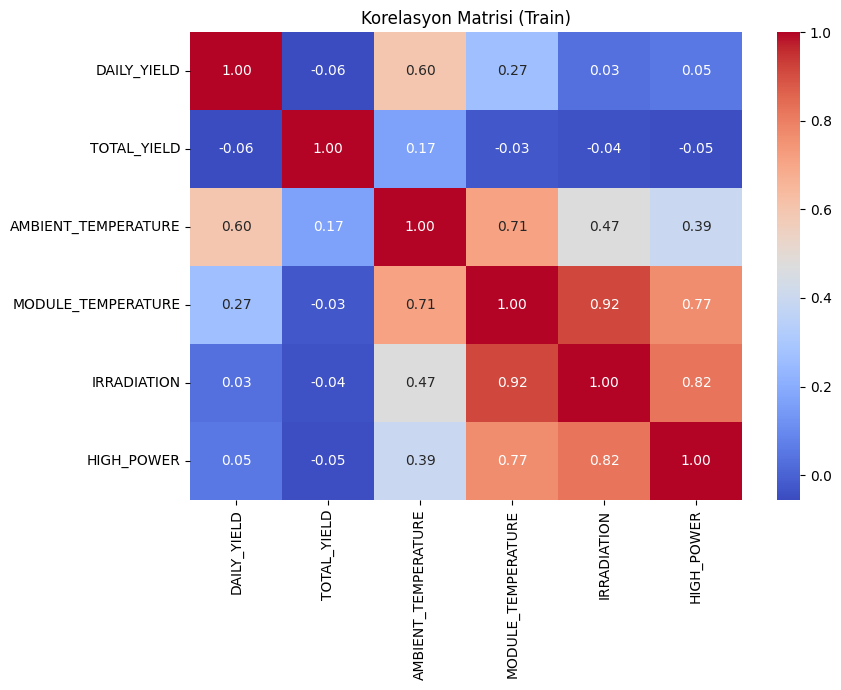

IRRADIATION            0.823633
MODULE_TEMPERATURE     0.768717
AMBIENT_TEMPERATURE    0.394596
DAILY_YIELD            0.052177
TOTAL_YIELD            0.049380

--- YONTEM 2: SelectKBest ---
            Ozellik      F-Skoru
        IRRADIATION 92944.744013
 MODULE_TEMPERATURE 63656.554105
AMBIENT_TEMPERATURE  8126.921937
        DAILY_YIELD   120.299017
        TOTAL_YIELD   107.713701

--- YONTEM 3: RFE ---
            Ozellik  Secildi  Siralama
 MODULE_TEMPERATURE     True         1
AMBIENT_TEMPERATURE     True         1
        IRRADIATION     True         1
        DAILY_YIELD    False         2
        TOTAL_YIELD    False         3

--- YONTEM 4: Mutual Information ---
            Ozellik  MI Skoru
AMBIENT_TEMPERATURE  0.627678
 MODULE_TEMPERATURE  0.623181
        IRRADIATION  0.619101
        TOTAL_YIELD  0.302354
        DAILY_YIELD  0.215895

--- SECILEN OZELLIKLER (4 yontem kesisimi) ---
['IRRADIATION', 'MODULE_TEMPERATURE', 'AMBIENT_TEMPERATURE']


In [15]:
# ==================================================
# BOLUM 4 - Normalizasyon ve Ozellik Secimi (Gorev 2)
# ==================================================

# 4.1 MinMaxScaler - SADECE train'e fit et
print('--- 4.1 NORMALIZASYON ---')
scaler = MinMaxScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_val_sc   = pd.DataFrame(scaler.transform(X_val),       columns=feature_cols)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=feature_cols)
print('Scaler sadece train verisine fit edildi.')
display(X_train_sc.describe().round(3))

# 4.2 Yontem 1: Korelasyon Analizi
print('\n--- YONTEM 1: KORELASYON ---')
corr_df = X_train_sc.copy()
corr_df['HIGH_POWER'] = y_train.values
plt.figure(figsize=(9, 7))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f')
plt.title('Korelasyon Matrisi (Train)')
plt.tight_layout()
plt.show()
print(corr_df.corr()['HIGH_POWER'].drop('HIGH_POWER').abs().sort_values(ascending=False).to_string())

# 4.3 Yontem 2: SelectKBest (F-istatistigi)
print('\n--- YONTEM 2: SelectKBest ---')
skb = SelectKBest(score_func=f_classif, k='all')
skb.fit(X_train_sc, y_train)
kbest_df = pd.DataFrame({'Ozellik': feature_cols, 'F-Skoru': skb.scores_}).sort_values('F-Skoru', ascending=False)
print(kbest_df.to_string(index=False))

# 4.4 Yontem 3: RFE
print('\n--- YONTEM 3: RFE ---')
rfe = RFE(estimator=LogisticRegression(max_iter=1000), n_features_to_select=3, step=1)
rfe.fit(X_train_sc, y_train)
rfe_df = pd.DataFrame({'Ozellik': feature_cols, 'Secildi': rfe.support_, 'Siralama': rfe.ranking_}).sort_values('Siralama')
print(rfe_df.to_string(index=False))

# 4.5 Yontem 4: Mutual Information
print('\n--- YONTEM 4: Mutual Information ---')
mi = mutual_info_classif(X_train_sc, y_train, random_state=42)
mi_df = pd.DataFrame({'Ozellik': feature_cols, 'MI Skoru': mi}).sort_values('MI Skoru', ascending=False)
print(mi_df.to_string(index=False))

# Sonuc: 4 yontemin kesisimi
print('\n--- SECILEN OZELLIKLER (4 yontem kesisimi) ---')
selected_features = ['IRRADIATION', 'MODULE_TEMPERATURE', 'AMBIENT_TEMPERATURE']
print(selected_features)
X_train_sel = X_train_sc[selected_features].reset_index(drop=True)
X_val_sel   = X_val_sc[selected_features].reset_index(drop=True)
X_test_sel  = X_test_sc[selected_features].reset_index(drop=True)

In [ ]:
# ==================================================
# BOLUM 5 - Model Egitimi (Gorev 3)
# ==================================================

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train_sel, y_train)
    trained_models[name] = model

print('Modeller egitildi.')


### Confusion Matrix Yorumu

Confusion matrix, modelin düşük üretim (0) ve yüksek üretim (1) sınıflarını ne kadar doğru ayırdığını gösterir.

TN / TP: Doğru tahminler
FP / FN: Hatalı tahminler
Bu problemde sınıfların karıştırılma oranı, model performansını yorumlamak için önemlidir.


In [ ]:
# ==================================================
# BOLUM 5.1 - Confusion Matrix (Test Seti)
# ==================================================

print('--- CONFUSION MATRIX - TEST SETI ---')

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
cm_rows = []

for i, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test_sel)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    cm_rows.append({
        'Model': name,
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp,
        'Yanlis Sinif.': f'{fp + fn} / {len(y_test)}',
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
    })

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Dusuk', 'Yuksek']
    )
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='d')
    axes[i].set_title(name, fontsize=10)

axes[-1].set_visible(False)
plt.suptitle('Confusion Matrix - Test Seti', fontsize=13)
plt.tight_layout()
plt.show()

cm_summary_df = pd.DataFrame(cm_rows).sort_values('Accuracy', ascending=False)
display(cm_summary_df)


### Model Karsilastirma

Bu çalışmada 5 farklı sınıflandırma modeli karşılaştırılmıştır:

Logistic Regression
Random Forest
KNN
Naive Bayes
XGBoost
Modeller Accuracy, Precision, Recall ve F1 skorlarına göre değerlendirilmiştir. Final model olarak test performansı en yüksek olan model seçilmiştir.


--- 6.1 UCLU METRIK TABLOSU ---


Accuracy                 Precision                  \
                       Train     Val    Test     Train     Val    Test   
Model                                                                    
KNN                   0.9743  0.9719  0.9719    0.9651  0.9625  0.9609   
Logistic Regression   0.9506  0.9499  0.9483    0.9511  0.9528  0.9485   
Naive Bayes           0.9155  0.9122  0.9169    0.9118  0.9139  0.9153   
Random Forest         0.9759  0.9734  0.9737    0.9653  0.9637  0.9621   
XGBoost               0.9758  0.9740  0.9742    0.9650  0.9639  0.9623   

                     Recall                      F1                  
                      Train     Val    Test   Train     Val    Test  
Model                                                                
KNN                  0.9828  0.9805  0.9818  0.9739  0.9714  0.9712  
Logistic Regression  0.9473  0.9440  0.9443  0.9492  0.9484  0.9464  
Naive Bayes          0.9148  0.9053  0.9126  0.9133  0.9096  0.9139  
Random Forest        0.9859  0.9825  0.9844  0.9755  0.9730  0.9731  
XGBoost              0.9862  0.9836  0.9851  0.9755  0.9737  0.9736


--- 6.2 ROC ANALIZI (Train vs Validation) ---


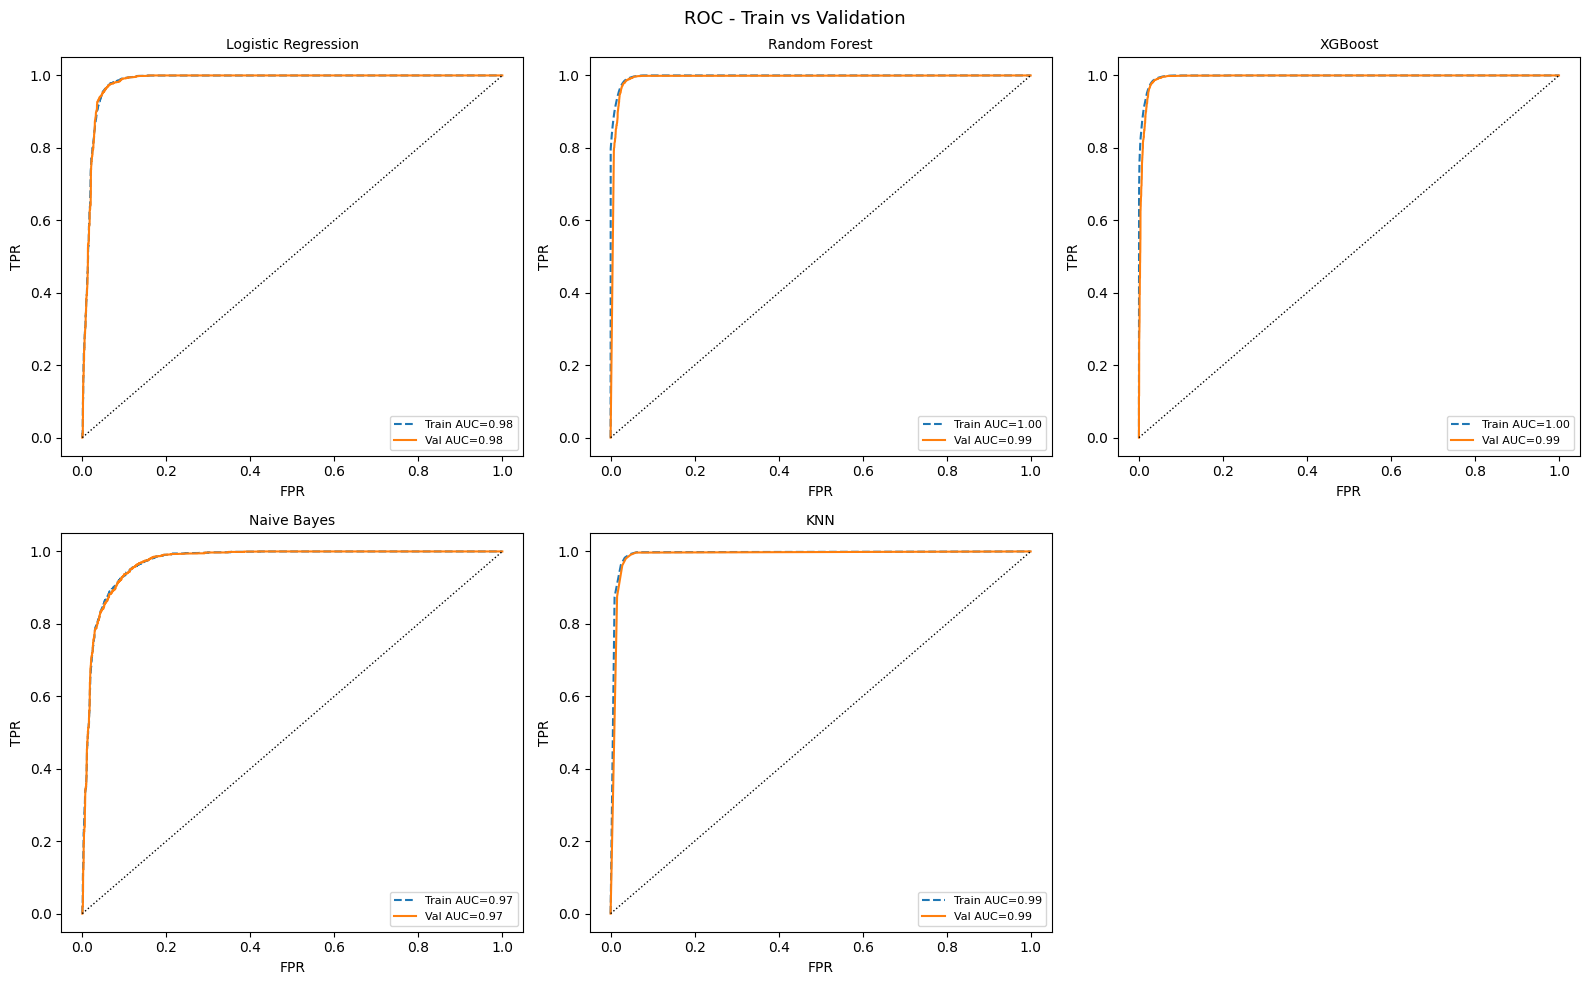

--- 6.3 PRECISION-RECALL (Train vs Validation) ---


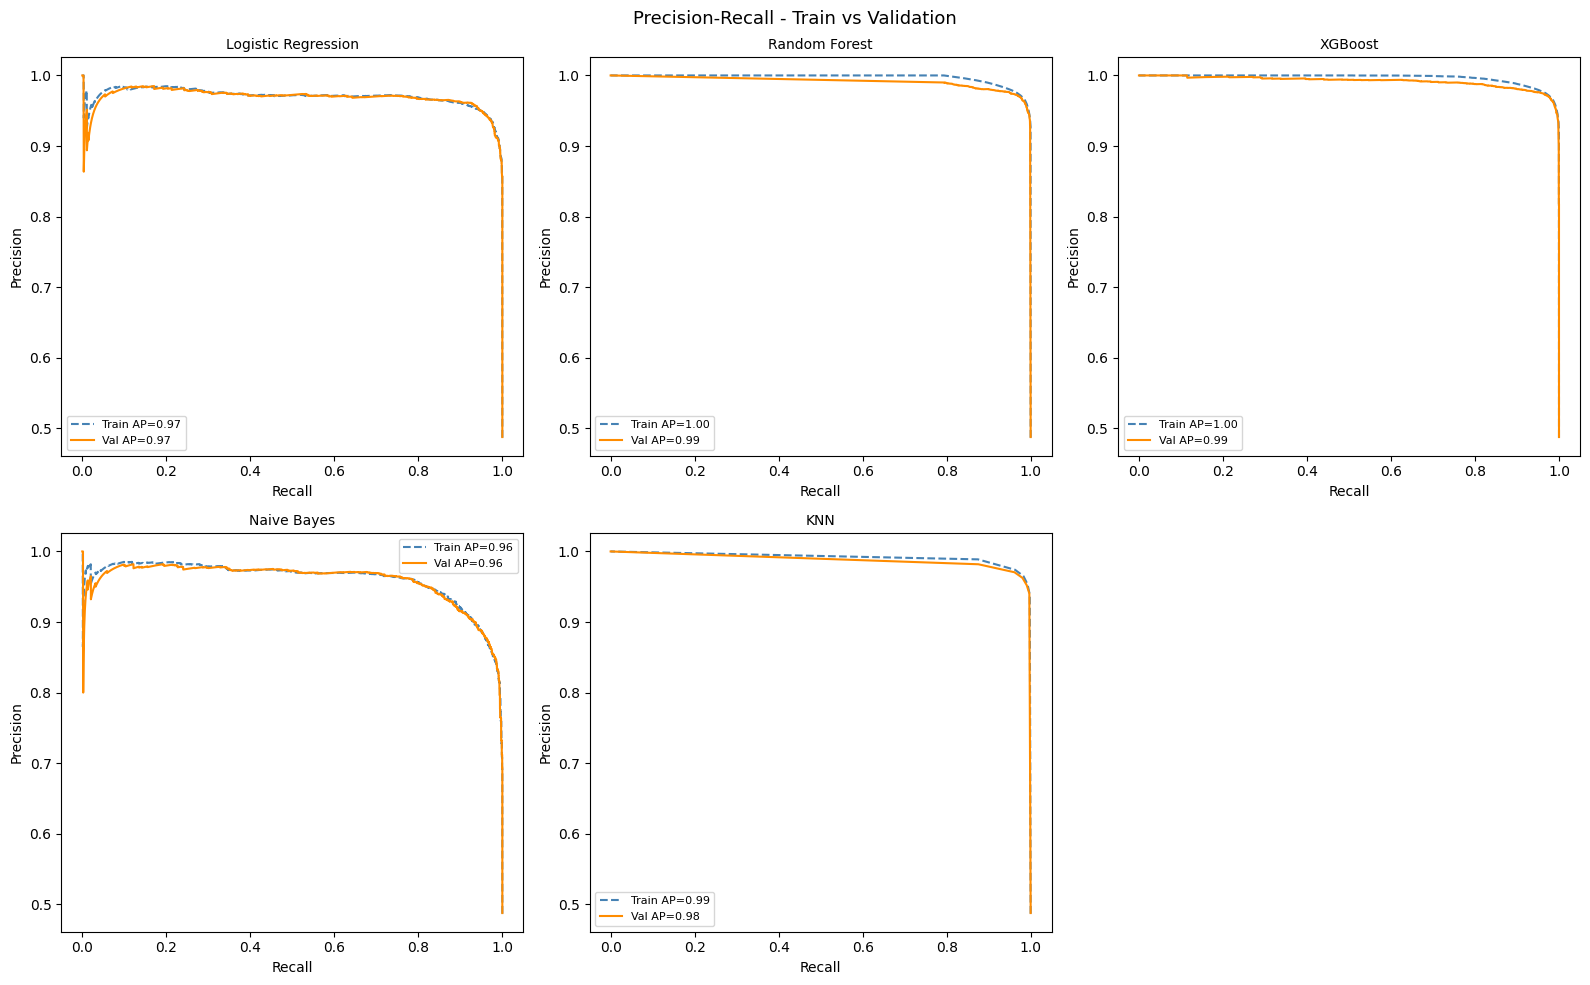

--- 6.4 FEATURE IMPORTANCE ---


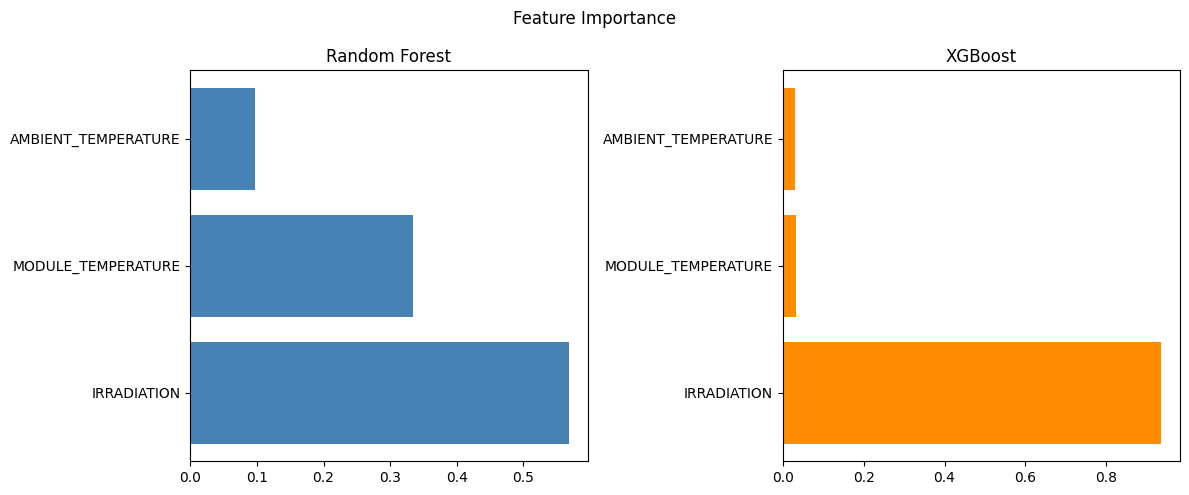


En basarili model: XGBoost
best_model.pkl, xgboost_model.pkl, scaler.pkl, selected_features.pkl kaydedildi.


In [17]:
# ==================================================
# BOLUM 6 - Model Degerlendirme (Gorev 4)
# ==================================================

# 6.1 Uclu Metrik Tablosu (Train / Val / Test) + F1
print('--- 6.1 UCLU METRIK TABLOSU ---')
rows = []
for name, model in trained_models.items():
    for sname, Xs, ys in [('Train', X_train_sel, y_train),
                           ('Val',   X_val_sel,   y_val),
                           ('Test',  X_test_sel,  y_test)]:
        yp = model.predict(Xs)
        rows.append({
            'Model'    : name,
            'Set'      : sname,
            'Accuracy' : round(accuracy_score(ys, yp), 4),
            'Precision': round(precision_score(ys, yp, zero_division=0), 4),
            'Recall'   : round(recall_score(ys, yp, zero_division=0), 4),
            'F1'       : round(f1_score(ys, yp, zero_division=0), 4),
        })
metrics_df = pd.DataFrame(rows)
pivot = metrics_df.pivot_table(
    index='Model', columns='Set',
    values=['Accuracy', 'Precision', 'Recall', 'F1']
)
pivot = pivot.reindex(columns=pd.MultiIndex.from_product(
    [['Accuracy', 'Precision', 'Recall', 'F1'], ['Train', 'Val', 'Test']]
))
display(pivot)

# 6.2 ROC Analizi (Train + Val ayni grafik)
print('\n--- 6.2 ROC ANALIZI (Train vs Validation) ---')
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, (name, model) in enumerate(trained_models.items()):
    ax = axes[i]
    for sname, Xs, ys, ls in [('Train', X_train_sel, y_train, '--'),
                                ('Val',   X_val_sel,   y_val,   '-')]:
        sc = (model.predict_proba(Xs)[:, 1]
              if hasattr(model, 'predict_proba')
              else model.decision_function(Xs))
        fpr, tpr, _ = roc_curve(ys, sc)
        ax.plot(fpr, tpr, ls=ls, label=f'{sname} AUC={auc(fpr, tpr):.2f}')
    ax.plot([0, 1], [0, 1], 'k:', lw=1)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.legend(fontsize=8)
axes[-1].set_visible(False)
plt.suptitle('ROC - Train vs Validation', fontsize=13)
plt.tight_layout(); plt.show()

# 6.3 Precision-Recall Egrisi (Train + Validation)
print('--- 6.3 PRECISION-RECALL (Train vs Validation) ---')
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
pr_styles  = {'Train': '--',        'Val': '-'}
for i, (name, model) in enumerate(trained_models.items()):
    ax = axes[i]
    for sname, Xs, ys in [('Train', X_train_sel, y_train),
                            ('Val',   X_val_sel,   y_val)]:
        sc = (model.predict_proba(Xs)[:, 1]
              if hasattr(model, 'predict_proba')
              else model.decision_function(Xs))
        p, r, _ = precision_recall_curve(ys, sc)
        ap = average_precision_score(ys, sc)
        ax.plot(r, p, ls=pr_styles[sname],
                label=f'{sname} AP={ap:.2f}')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.legend(fontsize=8)
axes[-1].set_visible(False)
plt.suptitle('Precision-Recall - Train vs Validation', fontsize=13)
plt.tight_layout(); plt.show()

# 6.4 Feature Importance (RF + XGBoost)
print('--- 6.4 FEATURE IMPORTANCE ---')
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].barh(selected_features, trained_models['Random Forest'].feature_importances_)
axes[0].set_title('Random Forest')
axes[1].barh(selected_features, trained_models['XGBoost'].feature_importances_)
axes[1].set_title('XGBoost')
plt.suptitle('Feature Importance')
plt.tight_layout(); plt.show()

# En iyi modeli bul ve kaydet
best_name = (metrics_df[metrics_df['Set'] == 'Test']
             .sort_values('Accuracy', ascending=False)
             .iloc[0]['Model'])
best_model = trained_models[best_name]
print(f'\nEn basarili model: {best_name}')

MODEL_DIR = PROJECT_ROOT / 'modeller'
MODEL_DIR.mkdir(exist_ok=True)

with open(MODEL_DIR / 'best_model.pkl', 'wb') as f: pickle.dump(best_model, f)
with open(MODEL_DIR / 'xgboost_model.pkl', 'wb') as f: pickle.dump(trained_models['XGBoost'], f)
with open(MODEL_DIR / 'scaler.pkl', 'wb') as f: pickle.dump(scaler, f)
with open(MODEL_DIR / 'selected_features.pkl', 'wb') as f: pickle.dump(selected_features, f)
print('Model dosyalari modeller/ klasorune kaydedildi.')


### SHAP Analizi

SHAP analizi, XGBoost modelinin tahminlerinde hangi ozelliklerin daha etkili oldugunu gormek icin kullanilmistir.

Bu bolumde summary plot, bar plot ve waterfall plot ile model kararlari yorumlanmistir.


--- 7.1 SHAP SUMMARY PLOT ---


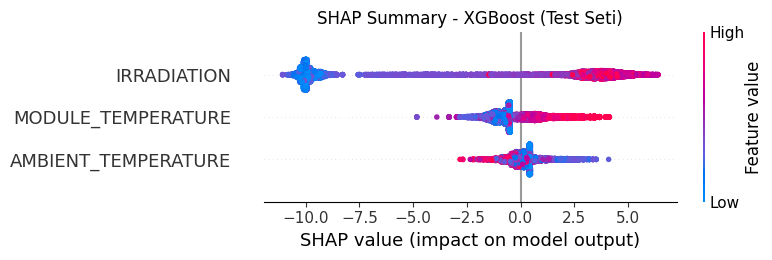

--- 7.2 SHAP BAR PLOT (Ortalama Mutlak Etki) ---


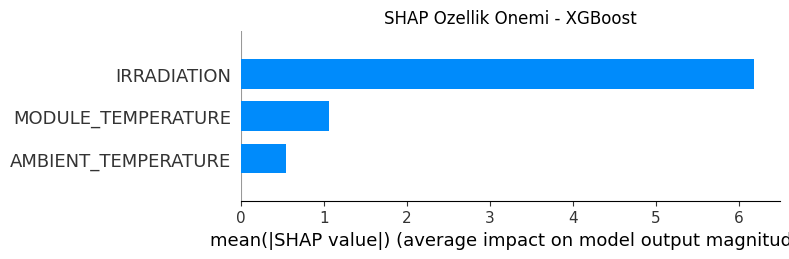

--- 7.3 SHAP WATERFALL (Tek Ornek Aciklamasi) ---


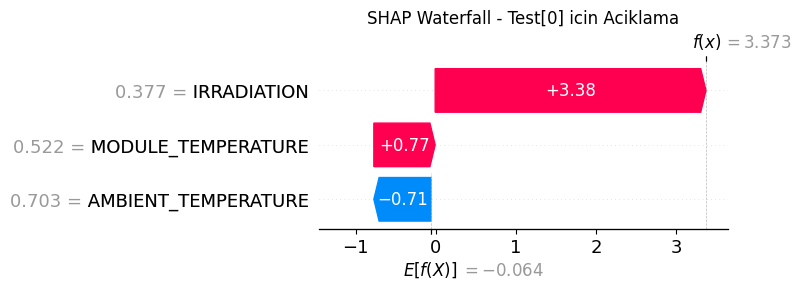


SHAP Ortalama Mutlak Deger Siralamasi:
  IRRADIATION              : ort. |SHAP| = 6.1861
  MODULE_TEMPERATURE       : ort. |SHAP| = 1.0601
  AMBIENT_TEMPERATURE      : ort. |SHAP| = 0.5484

=> En yuksek SHAP degerine sahip ozellik modelin kararinda en etkilidir.


In [18]:
# ==================================================
# BOLUM 7 - Kara Kutu Aciklanabilirligi (SHAP)
# ==================================================
# En basarili model (XGBoost) icin SHAP ile tahmin gerekceleri aciklanmaktadir.
# SHAP degeri: bir ozelligi ortalama tahminden ne kadar uzaklastirdigini gosterir.

print('--- 7.1 SHAP SUMMARY PLOT ---')
explainer   = shap.TreeExplainer(trained_models['XGBoost'])
shap_values = explainer.shap_values(X_test_sel)

plt.figure()
shap.summary_plot(shap_values, X_test_sel,
                  feature_names=selected_features, show=False)
plt.title('SHAP Summary - XGBoost (Test Seti)')
plt.tight_layout(); plt.show()

print('--- 7.2 SHAP BAR PLOT (Ortalama Mutlak Etki) ---')
plt.figure()
shap.summary_plot(shap_values, X_test_sel,
                  feature_names=selected_features,
                  plot_type='bar', show=False)
plt.title('SHAP Ozellik Onemi - XGBoost')
plt.tight_layout(); plt.show()

print('--- 7.3 SHAP WATERFALL (Tek Ornek Aciklamasi) ---')
exp = shap.Explanation(
    values      = shap_values[0:1],
    base_values = explainer.expected_value,
    data        = X_test_sel.values[0:1],
    feature_names = selected_features
)
shap.plots.waterfall(exp[0], show=False)
plt.title('SHAP Waterfall - Test[0] icin Aciklama')
plt.tight_layout(); plt.show()

print('\nSHAP Ortalama Mutlak Deger Siralamasi:')
mean_abs = pd.Series(
    dict(zip(selected_features, abs(shap_values).mean(axis=0)))
).sort_values(ascending=False)
for feat, val in mean_abs.items():
    print(f'  {feat:25s}: ort. |SHAP| = {val:.4f}')
print('\n=> En yuksek SHAP degerine sahip ozellik modelin kararinda en etkilidir.')
